# Ship Survival Prediction using Naive Bayes

**Project focus:** Project focuses on predicting whether a passenger survived or not using demographic and travel-related varibale using the Titanic/ship passenger dataset.

## 1. Import Libraries
We use Pandas and NumPy for data handling, Matplotlib/Seaborn for visualization, and Scikit-learn for model building and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset
The dataset contains passenger details such as class, gender, age, fare, family members, embarkation point, and survival status.

In [2]:
df = pd.read_csv('ship.csv')
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


## 3. Basic Data Understanding

In [3]:
print('Dataset shape:', df.shape)
df.info()

Dataset shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include='all')

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
count,891.000000,891,891.000000,891,714.000000,891.000000,891.000000,891,891.000000,204,889,891.000000
unique,NaN,891,NaN,2,NaN,NaN,NaN,681,NaN,147,3,NaN
top,NaN,"Braund, Mr. Owen Harris",NaN,male,NaN,NaN,NaN,1601,NaN,G6,S,NaN
freq,NaN,1,NaN,577,NaN,NaN,NaN,7,NaN,4,644,NaN
mean,446.000000,NaN,2.308642,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN,0.383838
std,257.353842,NaN,0.836071,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN,0.486592
min,1.000000,NaN,1.000000,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
25%,223.500000,NaN,2.000000,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN,0.000000
50%,446.000000,NaN,3.000000,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,0.000000
75%,668.500000,NaN,3.000000,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,1.000000


In [5]:
df.isnull().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

## 4. Target Variable Analysis
The target variable is **Survived**:

- `0` = Not survived
- `1` = Survived

This helps understand whether the data is balanced or imbalanced.

Survived
0    549
1    342
Name: count, dtype: int64

Survival percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


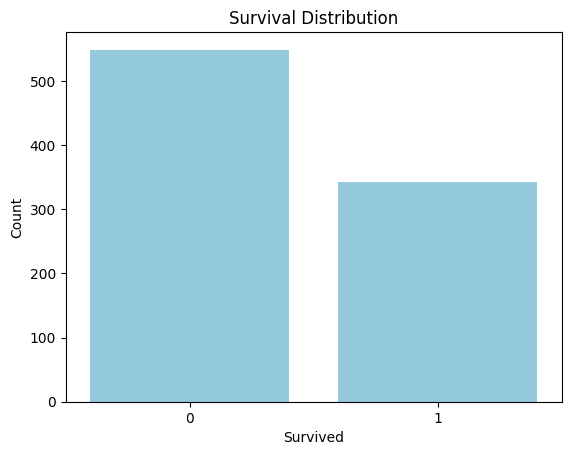

In [6]:
survival_counts = df['Survived'].value_counts()
survival_rate = df['Survived'].value_counts(normalize=True) * 100

print(survival_counts)
print('\nSurvival percentage:')
print(survival_rate.round(2))

sns.countplot(data=df, x='Survived', color='skyblue')
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

## 5. Business-Relevant Exploratory Analysis
These views help identify which passenger groups had better survival chances.

Survival rate by gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


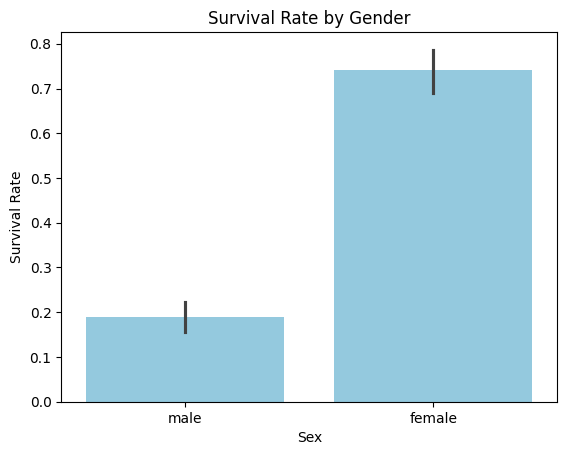

In [7]:
print('Survival rate by gender:')
print((df.groupby('Sex')['Survived'].mean() * 100).round(2))

sns.barplot(data=df, x='Sex', y='Survived', color='skyblue')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

Survival rate by passenger class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


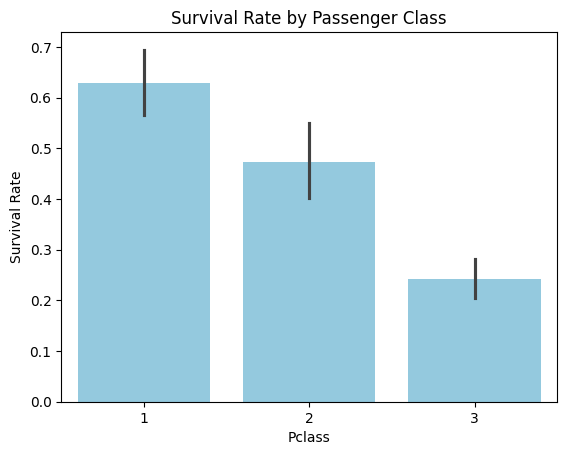

In [8]:
print('Survival rate by passenger class:')
print((df.groupby('Pclass')['Survived'].mean() * 100).round(2))

sns.barplot(data=df, x='Pclass', y='Survived', color='skyblue')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## 6. Feature Selection
For this model, we remove columns that are identifiers or have too many missing/unique values.

Removed columns:
- `PassengerId`, `Name`, `Ticket`: identification/text fields
- `Cabin`: very high missing values

Kept useful variables:
- `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

In [9]:
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 7. Train-Test Split
The dataset is split before preprocessing to avoid data leakage.  
`stratify=y` maintains the same survival ratio in training and testing data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 712
Testing rows: 179


## 8. Preprocessing and Model Pipeline
Missing values are handled inside the pipeline:

- Numerical columns: filled using median
- Categorical columns: filled using most frequent value and converted using one-hot encoding

Gaussian Naive Bayes is used because it is simple, fast, and useful for baseline classification problems.

In [11]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

numeric_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

## 9. Model Training

In [12]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 10. Model Evaluation

In [13]:
y_pred = model.predict(X_test)

train_accuracy = model.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print('Training Accuracy:', round(train_accuracy, 4))
print('Testing Accuracy:', round(test_accuracy, 4))

Training Accuracy: 0.7907
Testing Accuracy: 0.7877


[[91 19]
 [19 50]]


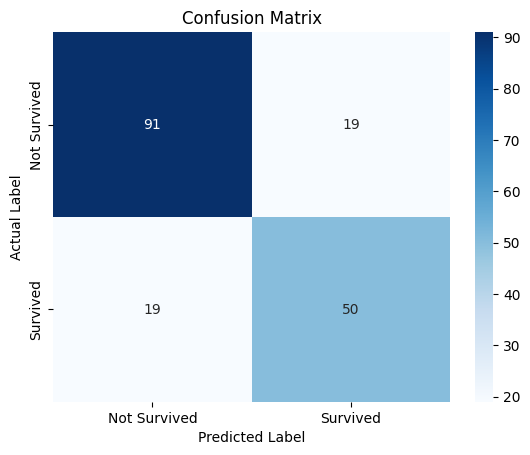

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.83      0.83      0.83       110
    Survived       0.72      0.72      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## 11. Cross Validation
Cross-validation checks if the model performance is stable across different data splits.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1')

print('Cross-validation accuracy scores:', cv_accuracy.round(4))
print('Mean CV accuracy:', round(cv_accuracy.mean(), 4))
print('Mean CV F1-score:', round(cv_f1.mean(), 4))

Cross-validation accuracy scores: [0.7821 0.8034 0.7978 0.736  0.8146]
Mean CV accuracy: 0.7868
Mean CV F1-score: 0.7258


## Observations

- The dataset has **891 passenger records** and the target variable is survival status.
- The survival class is slightly imbalanced: more passengers did not survive than survived.
- `Age`, `Cabin`, and `Embarked` contain missing values. `Cabin` was removed because it has many missing values.
- Gender and passenger class show strong business insight: females and higher-class passengers had better survival rates.
- The Naive Bayes model achieved around **79% test accuracy**, which is a reasonable baseline result.
- The training and testing accuracy are close, so the model does not show major overfitting.

## Conclusion

This project successfully applies **Naive Bayes classification** to predict passenger survival using demographic and travel-related features. The model gives a good baseline performance and provides useful analytical insights about survival patterns.

The project demonstrates data cleaning, feature selection, preprocessing, classification modelling, and performance interpretation. The model can be improved further by comparing it with Logistic Regression, Decision Tree, Random Forest, or Gradient Boosting models.